# NBL Cell Clustering

## Notebook Preferences

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format="retina"

## Libraries

In [2]:
import buckaroo  # noqa: F401
import lamindb as ln
import spatialdata as sd
from nbl.util import DaskLocalCluster
import nbl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Buckaroo has been enabled as the default DataFrame viewer.  To return to default dataframe visualization use `from buckaroo import disable; disable()`
💡 connected lamindb: srivarra/nbl_assets


In [3]:
pd.set_option("future.no_silent_downcasting", True)
pd.set_option("future.infer_string", False)
pd.set_option("mode.copy_on_write", True)

In [5]:
ln.settings.transform.stem_uid = "mqEhM9LGLNtM"
ln.settings.transform.version = "1"
ln.settings.sync_git_repo = "https://github.com/karadavis-lab/nbl.git"
run = ln.track()
run.transform

💡 notebook imports: bionty==0.48.0 buckaroo==0.6.12 lamindb==0.75.1 matplotlib==3.9.1.post1 nbl==0.1.dev2+gcbd4c32.d20240811 numpy==1.26.4 pandas==2.2.2 spatialdata==0.2.2.dev31+ga193a25 universal_pathlib==0.2.2
💡 saved: Transform(uid='mqEhM9LGLNtM5zKv', version='1', name='NBL Cell Clustering', key='00 - NBL Cell Clustering', type='notebook', created_by_id=1, updated_at='2024-08-12 17:16:33 UTC')
💡 saved: Run(uid='JWmYofZ49xAB4GWst9BO', transform_id=3, created_by_id=1)


Transform(uid='mqEhM9LGLNtM5zKv', version='1', name='NBL Cell Clustering', key='00 - NBL Cell Clustering', type='notebook', created_by_id=1, updated_at='2024-08-12 17:16:33 UTC')

In [6]:
ln.setup.settings.instance

Current instance: srivarra/nbl_assets
- owner: srivarra
- name: nbl_assets
- storage root: /Users/srivarra/Davis Lab/neuroblastoma/nbl/data/db
- storage region: None
- db: postgresql://srivarra:***@***:5555/nbl_db
- schema: {'bionty'}
- git_repo: None

In [7]:
cluster = DaskLocalCluster(n_workers=10, threads_per_worker=1)
cluster(open_dashboard=True)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 10
Total threads: 10,Total memory: 64.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:51460,Workers: 10
Dashboard: http://127.0.0.1:8787/status,Total threads: 10
Started: Just now,Total memory: 64.00 GiB
Comm: tcp://127.0.0.1:51491,Total threads: 1
Dashboard: http://127.0.0.1:51503/status,Memory: 6.40 GiB
Nanny: tcp://127.0.0.1:51463,


/Users/srivarra/Davis Lab/neuroblastoma/nbl/.venv/lib/python3.11/site-packages/bokeh/model/model.py:232: ResourceWarning: unclosed <ssl.SSLSocket fd=291, family=30, type=1, proto=0, laddr=('2601:645:8300:1130:61a1:1aca:26ac:354f', 53319, 0, 0), raddr=('2606:4700:3108::ac42:2840', 443, 0, 0)>
  return Ref(id=self._id)


## Get `FeatureSet` from Immune Markers Feature Set

In [8]:
immune_infiltrate_markers = nbl.ln.cell_marker_set_catalog("immune_infiltrate", "featureset")

In [9]:
nbl_sdata = sd.read_zarr(ln.Artifact.filter(key__contains="nbl.zarr").one().path)

In [13]:
nbl_wc = nbl_sdata.tables["whole_cell"]

nbl_wc_NBL = nbl_wc[nbl_wc.obs["pixie_cluster"] == "NBL_cell"]

In [10]:
def func(pct, allvals):
    """Returns a string with the percentage and absolute number of cells.

    Parameters
    ----------
    pct : _type_
        _description_
    allvals : _type_
        _description_

    Returns
    -------
    _type_
        _description_
    """
    absolute = int(np.round(pct / 100.0 * np.sum(allvals)))
    return f"{pct:.1f}% ({absolute:d} Cells)"

In [11]:
immune_infiltrate_markers.members.filter(name__contains="CD45").one().name

'CD45'

/Users/srivarra/Davis Lab/neuroblastoma/nbl/src/nbl/tl/basic.py:217: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["quantiles"] = {}


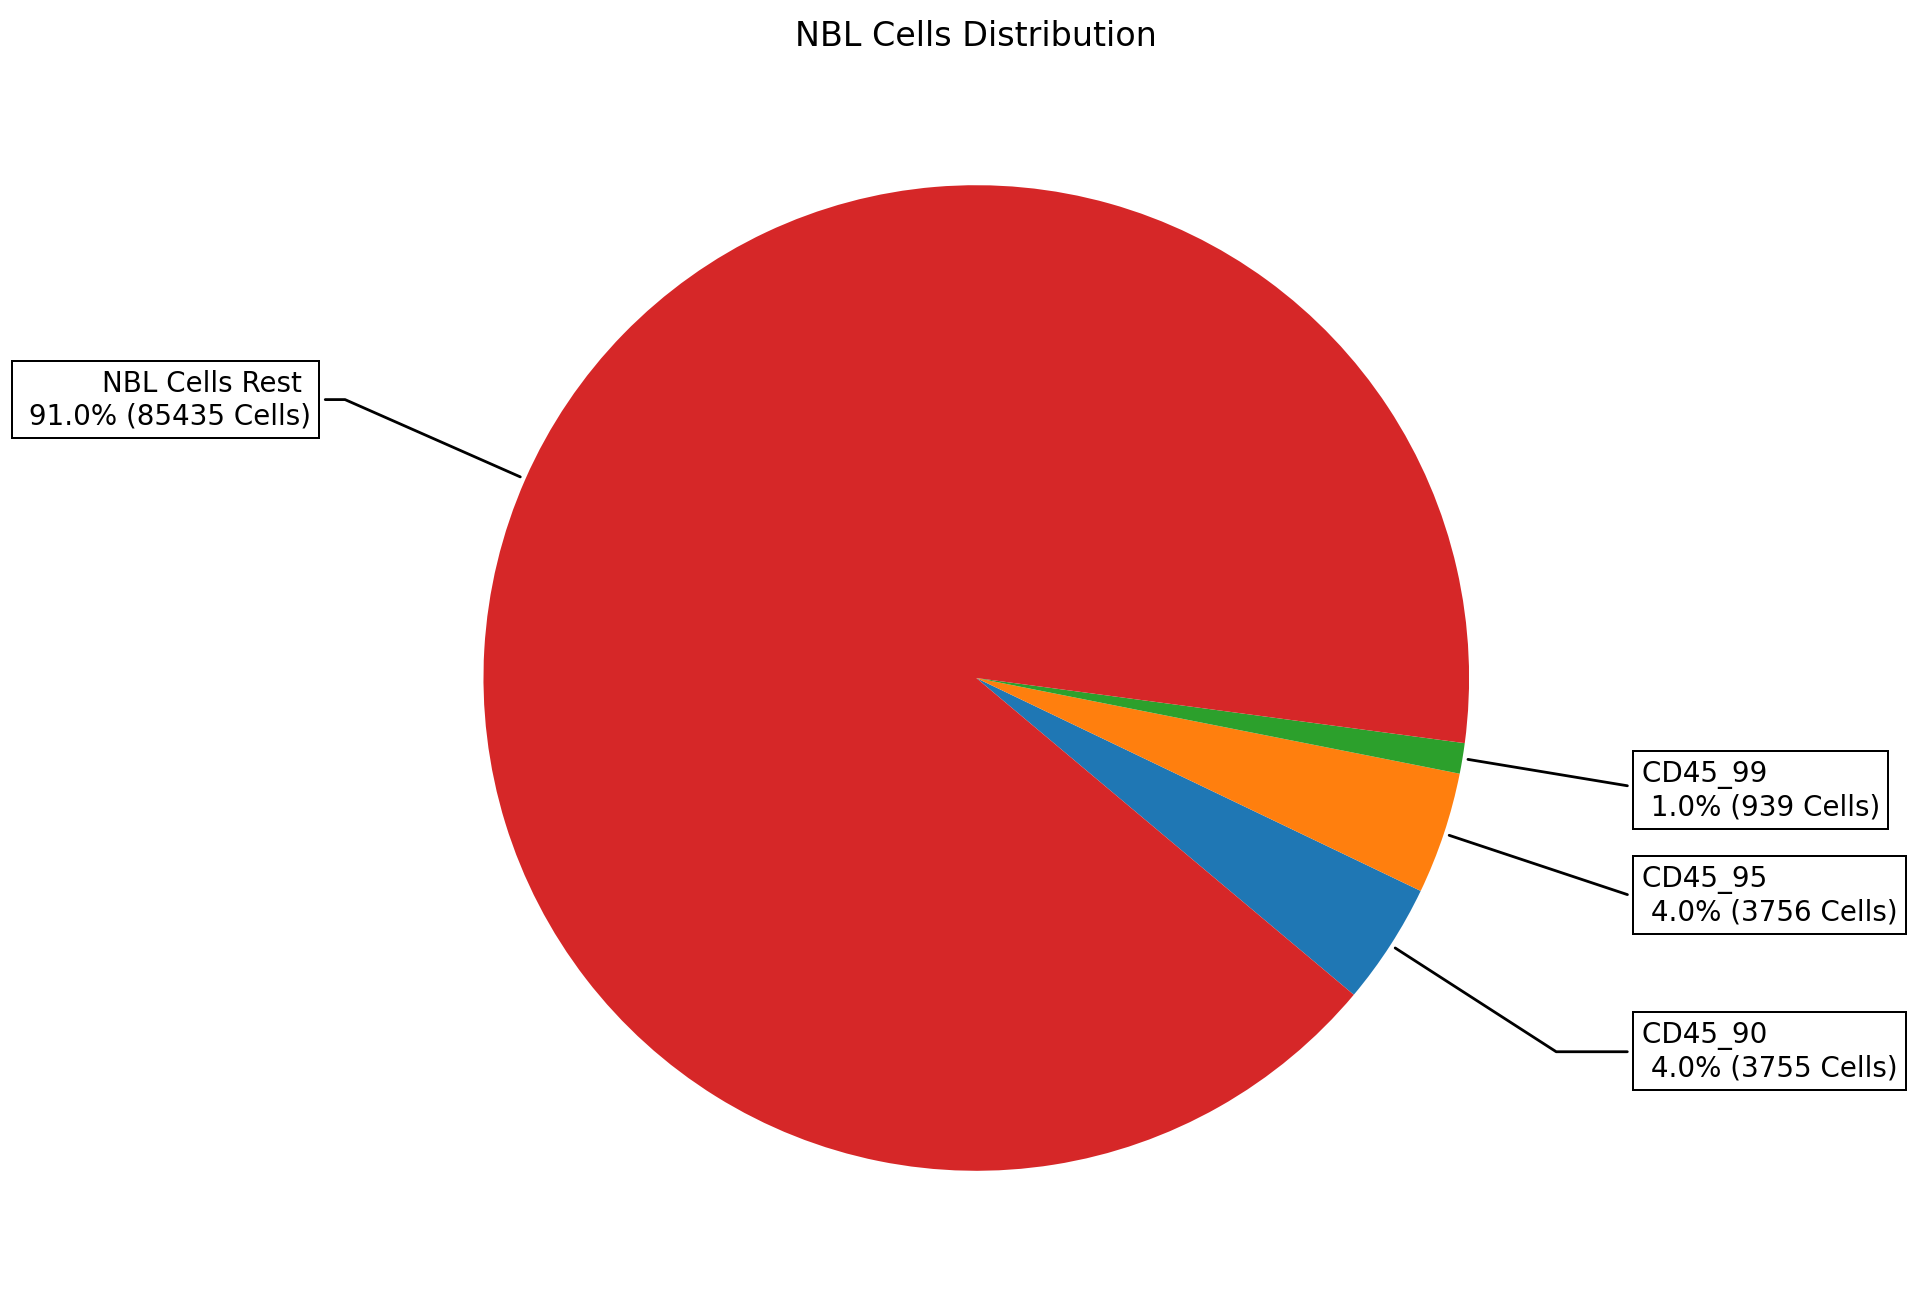

In [14]:
for i in [immune_infiltrate_markers.members.filter(name__contains="CD45").one().name]:
    marker = i
    nbl_wc_NBL__90 = nbl.tl.quantile(adata=nbl_wc_NBL, var=marker, q=0.90, filter_adata=True)
    nbl_wc_NBL__95 = nbl.tl.quantile(adata=nbl_wc_NBL, var=marker, q=0.95, filter_adata=True)
    nbl_wc_NBL__99 = nbl.tl.quantile(adata=nbl_wc_NBL, var=marker, q=0.99, filter_adata=True)

    nbl_wc_NBL.obs[f"{marker}_90"] = nbl_wc_NBL.obs_names.isin(nbl_wc_NBL__90.obs_names)
    nbl_wc_NBL.obs[f"{marker}_95"] = nbl_wc_NBL.obs_names.isin(nbl_wc_NBL__95.obs_names)
    nbl_wc_NBL.obs[f"{marker}_99"] = nbl_wc_NBL.obs_names.isin(nbl_wc_NBL__99.obs_names)

    n__90 = sum(nbl_wc_NBL.obs[f"{marker}_90"]) - (
        sum(nbl_wc_NBL.obs[f"{marker}_95"]) + sum(nbl_wc_NBL.obs[f"{marker}_99"])
    )
    n__95 = sum(nbl_wc_NBL.obs[f"{marker}_95"]) - sum(nbl_wc_NBL.obs[f"{marker}_99"])
    n__99 = sum(nbl_wc_NBL.obs[f"{marker}_99"])

    n_nbl_cells_rest = nbl_wc_NBL.n_obs - n__90 - n__95 - n__99

    sizes = [n__90, n__95, n__99, n_nbl_cells_rest]
    labels = [f"{marker}_90", f"{marker}_95", f"{marker}_99", "NBL Cells Rest"]

    fig, ax = plt.subplots(figsize=(16, 8), subplot_kw={"aspect": "equal"})

    wedges, texts = ax.pie(sizes, startangle=-40)

    bbox_props = {"boxstyle": "square,pad=0.3", "fc": "w", "ec": "k", "lw": 0.72}
    kw = {"arrowprops": {"arrowstyle": "-"}, "bbox": bbox_props, "zorder": 0, "va": "center"}

    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1) / 2.0 + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
        connectionstyle = f"angle,angleA=0,angleB={ang}"
        kw["arrowprops"].update({"connectionstyle": connectionstyle})
        ax.annotate(
            f"{labels[i]} \n {func(sizes[i] / sum(sizes) * 100, sizes)}",
            xy=(x, y),
            xytext=(1.35 * np.sign(x), 1.4 * y),
            horizontalalignment=horizontalalignment,
            **kw,
        )

    ax.set_title("NBL Cells Distribution")

    plt.show()

In [17]:
import seaborn.objects as so

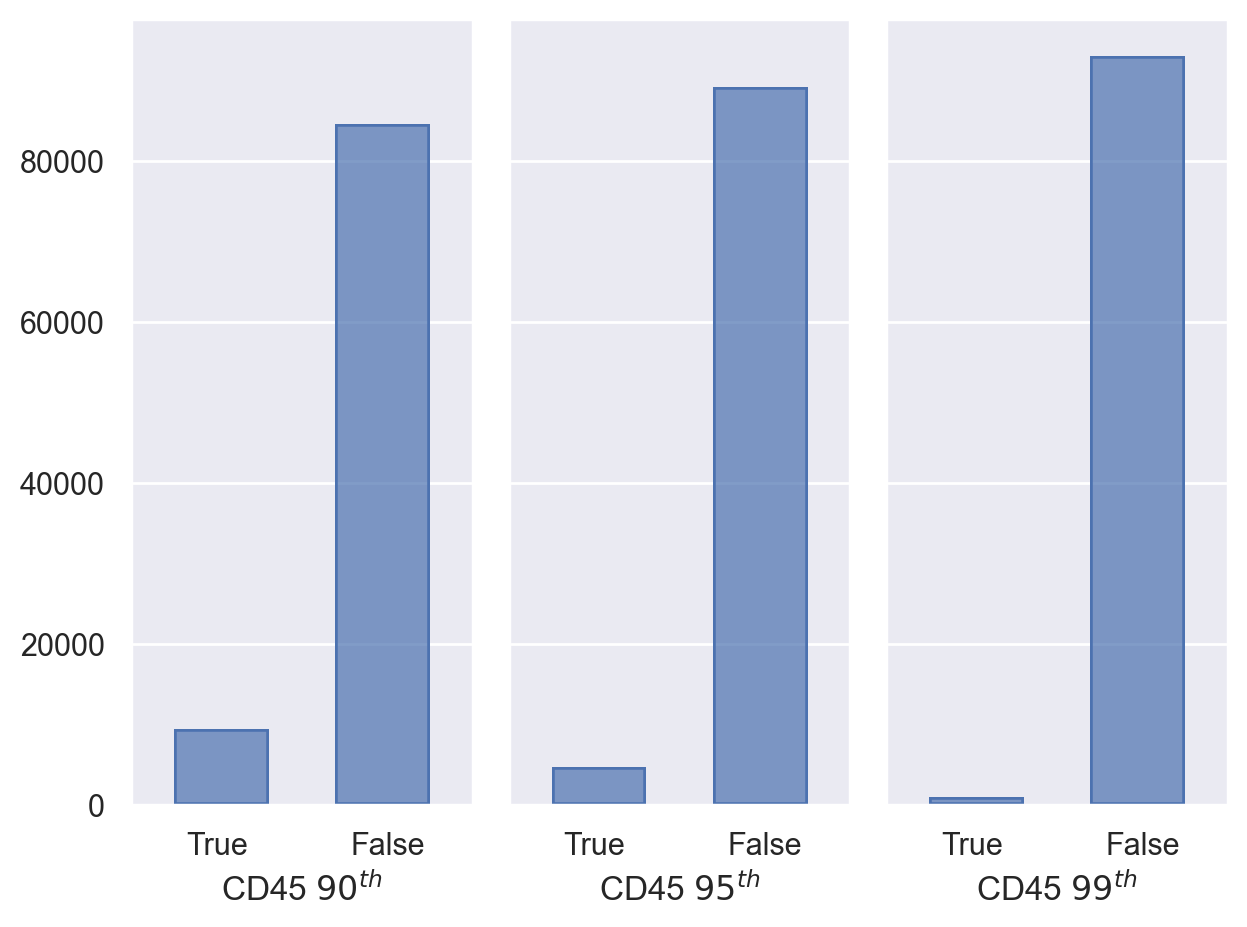

In [59]:
so.Plot(nbl_wc_NBL.obs).add(so.Bar(width=10), so.Hist(stat="count")).pair(x=["CD45_90", "CD45_95", "CD45_99"]).label(
    x0=r"CD45 $90^{th}$", x1=r"CD45 $95^{th}$", x2=r"CD45 $99^{th}$"
).share(x=True, y=True).show()

In [ ]:
nbl_wc_NBL.uns["quantiles"]

In [ ]:
nbl_wc_NBL.to_df()

In [61]:
nbl_markers = nbl.ln.cell_marker_set_catalog("neuroblastoma", "names")

In [63]:
import scanpy as sc

In [70]:
import pandas as pd


def combine_columns(row) -> str:
    """Combines columns into a single column based on the values in the columns.

    Parameters
    ----------
    row : pd.Series
        The row of the DataFrame.

    Returns
    -------
    str
        The combined column.
    """
    if row["CD45_99"]:
        return "Group_99"
    elif row["CD45_95"]:
        return "Group_95"
    elif row["CD45_90"]:
        return "Group_90"
    else:
        return "Rest"


# Apply the function to combine columns
nbl_wc_NBL.obs["Group"] = nbl_wc_NBL.obs.apply(combine_columns, axis=1)

# Check the new column
print(nbl_wc_NBL.obs["Group"].value_counts())

Group
Rest        84496
Group_90     4694
Group_95     3756
Group_99      939
Name: count, dtype: int64


/Users/srivarra/Davis Lab/neuroblastoma/nbl/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


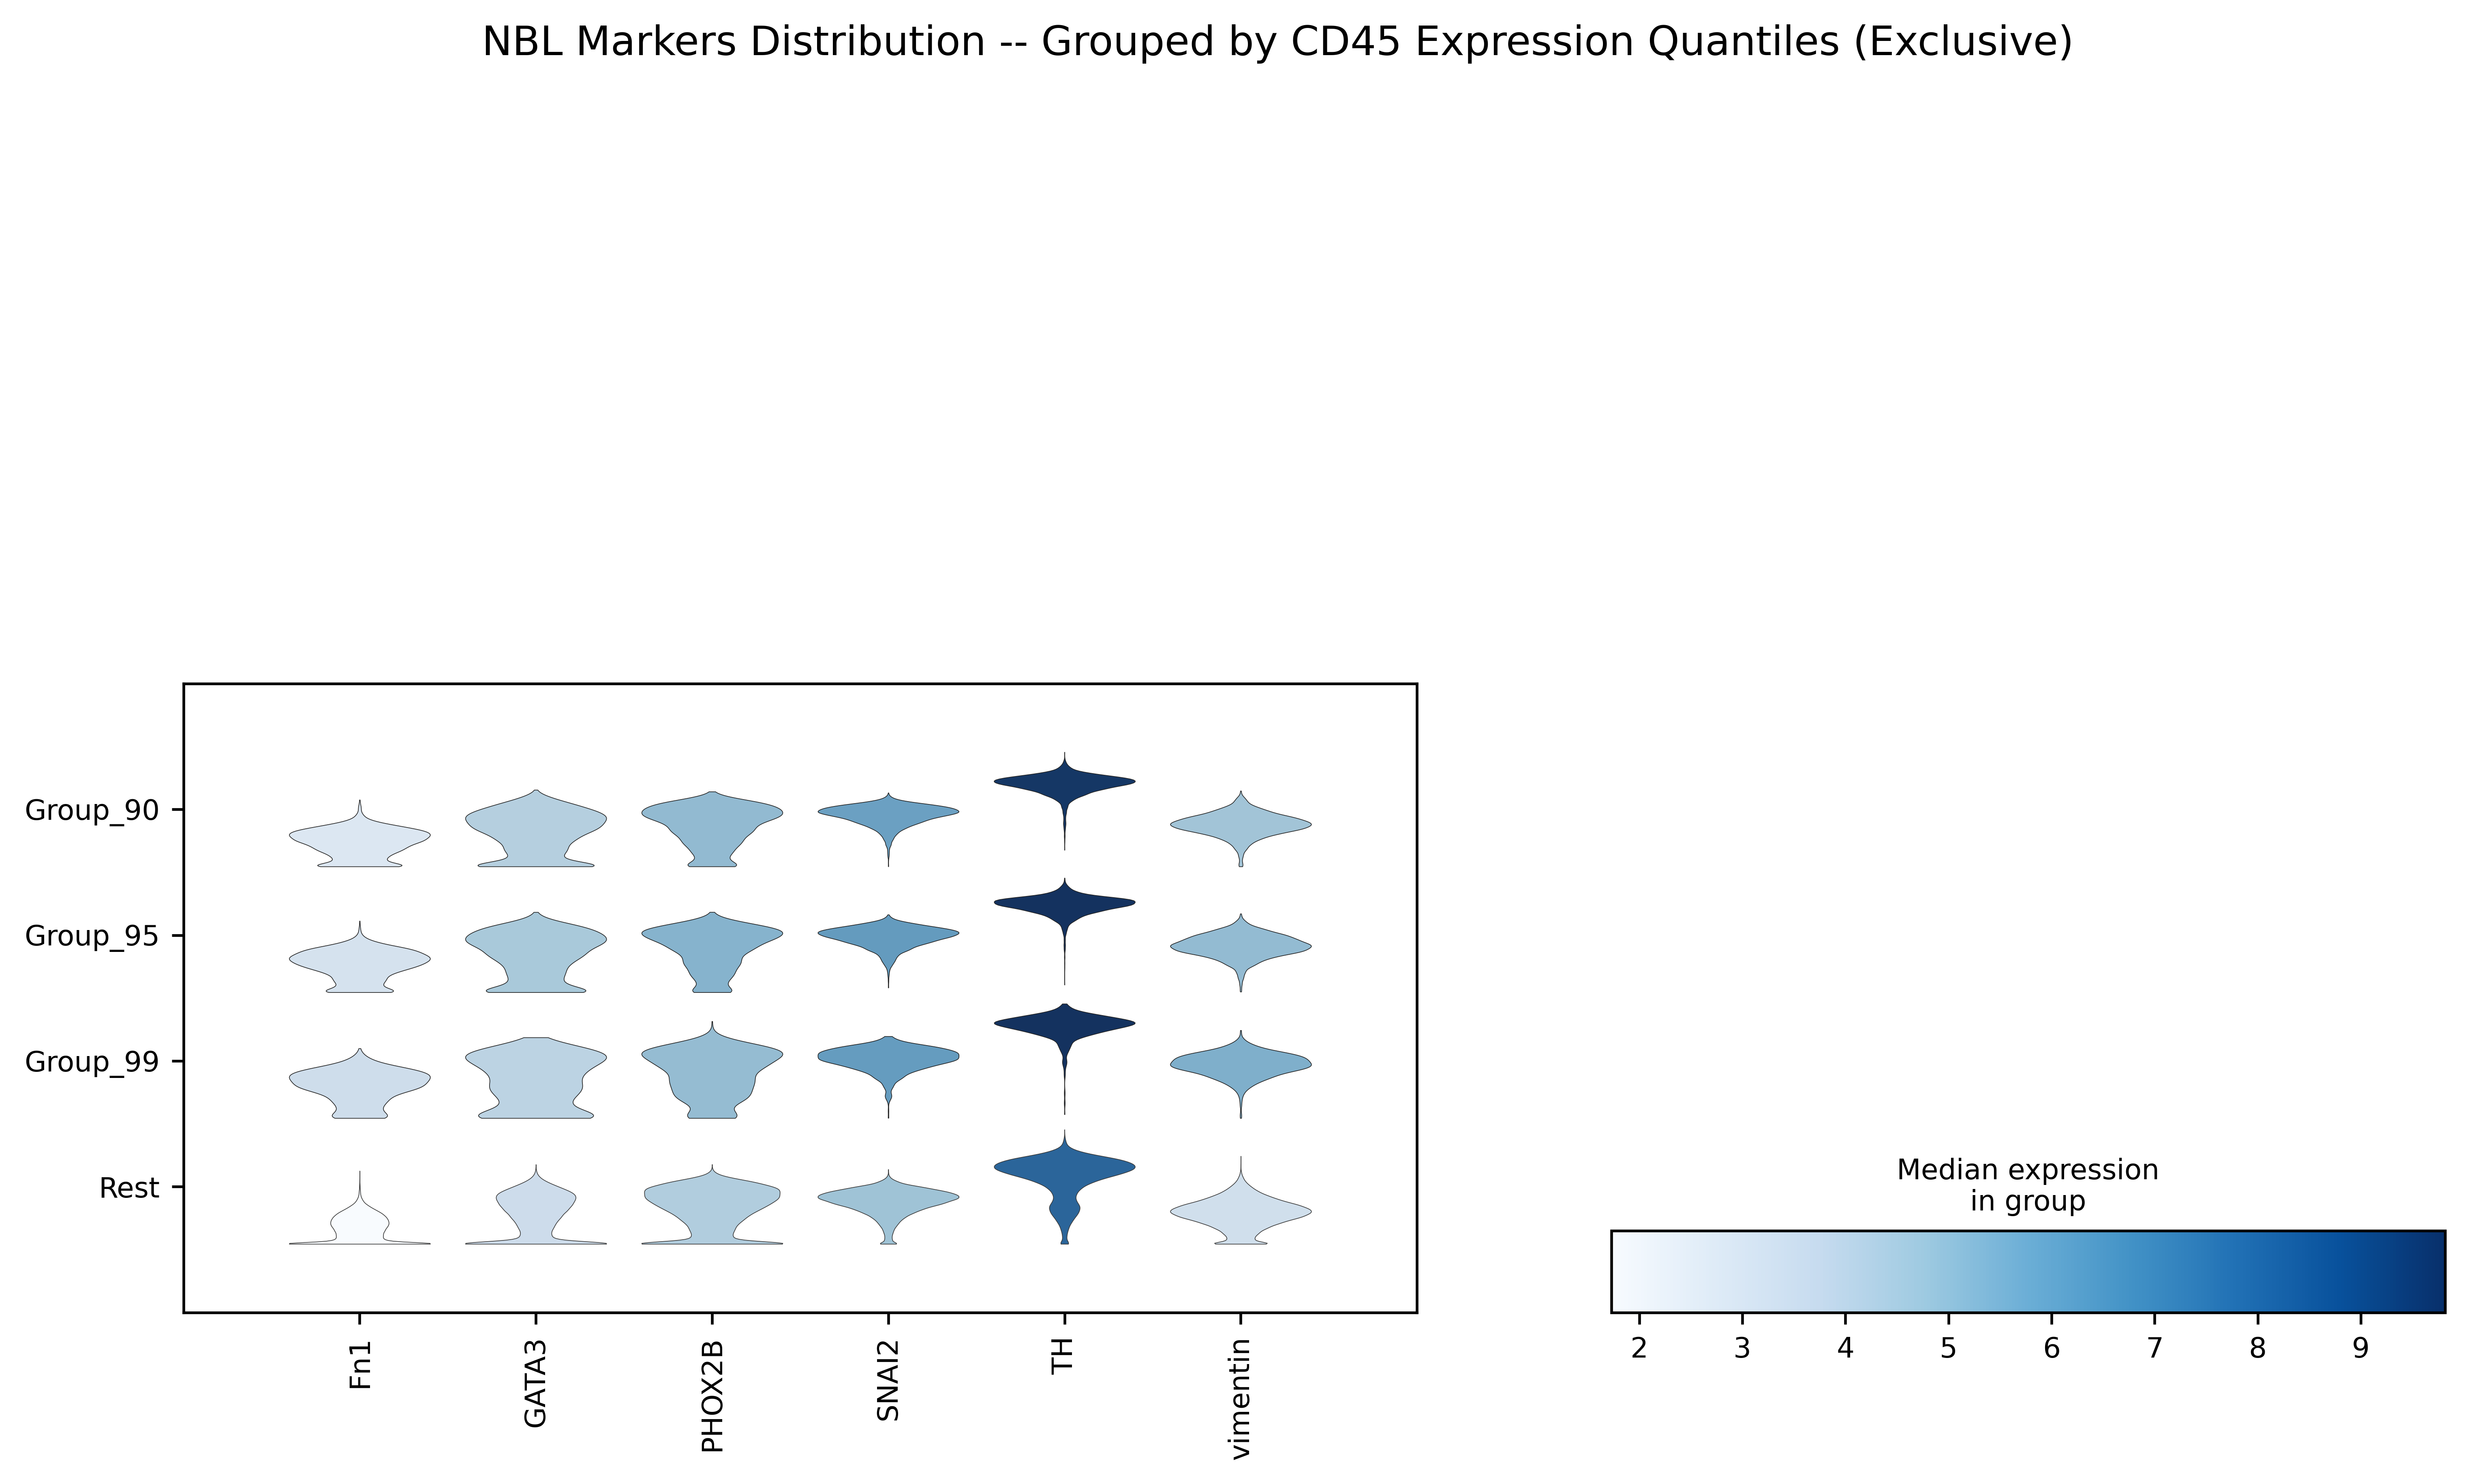

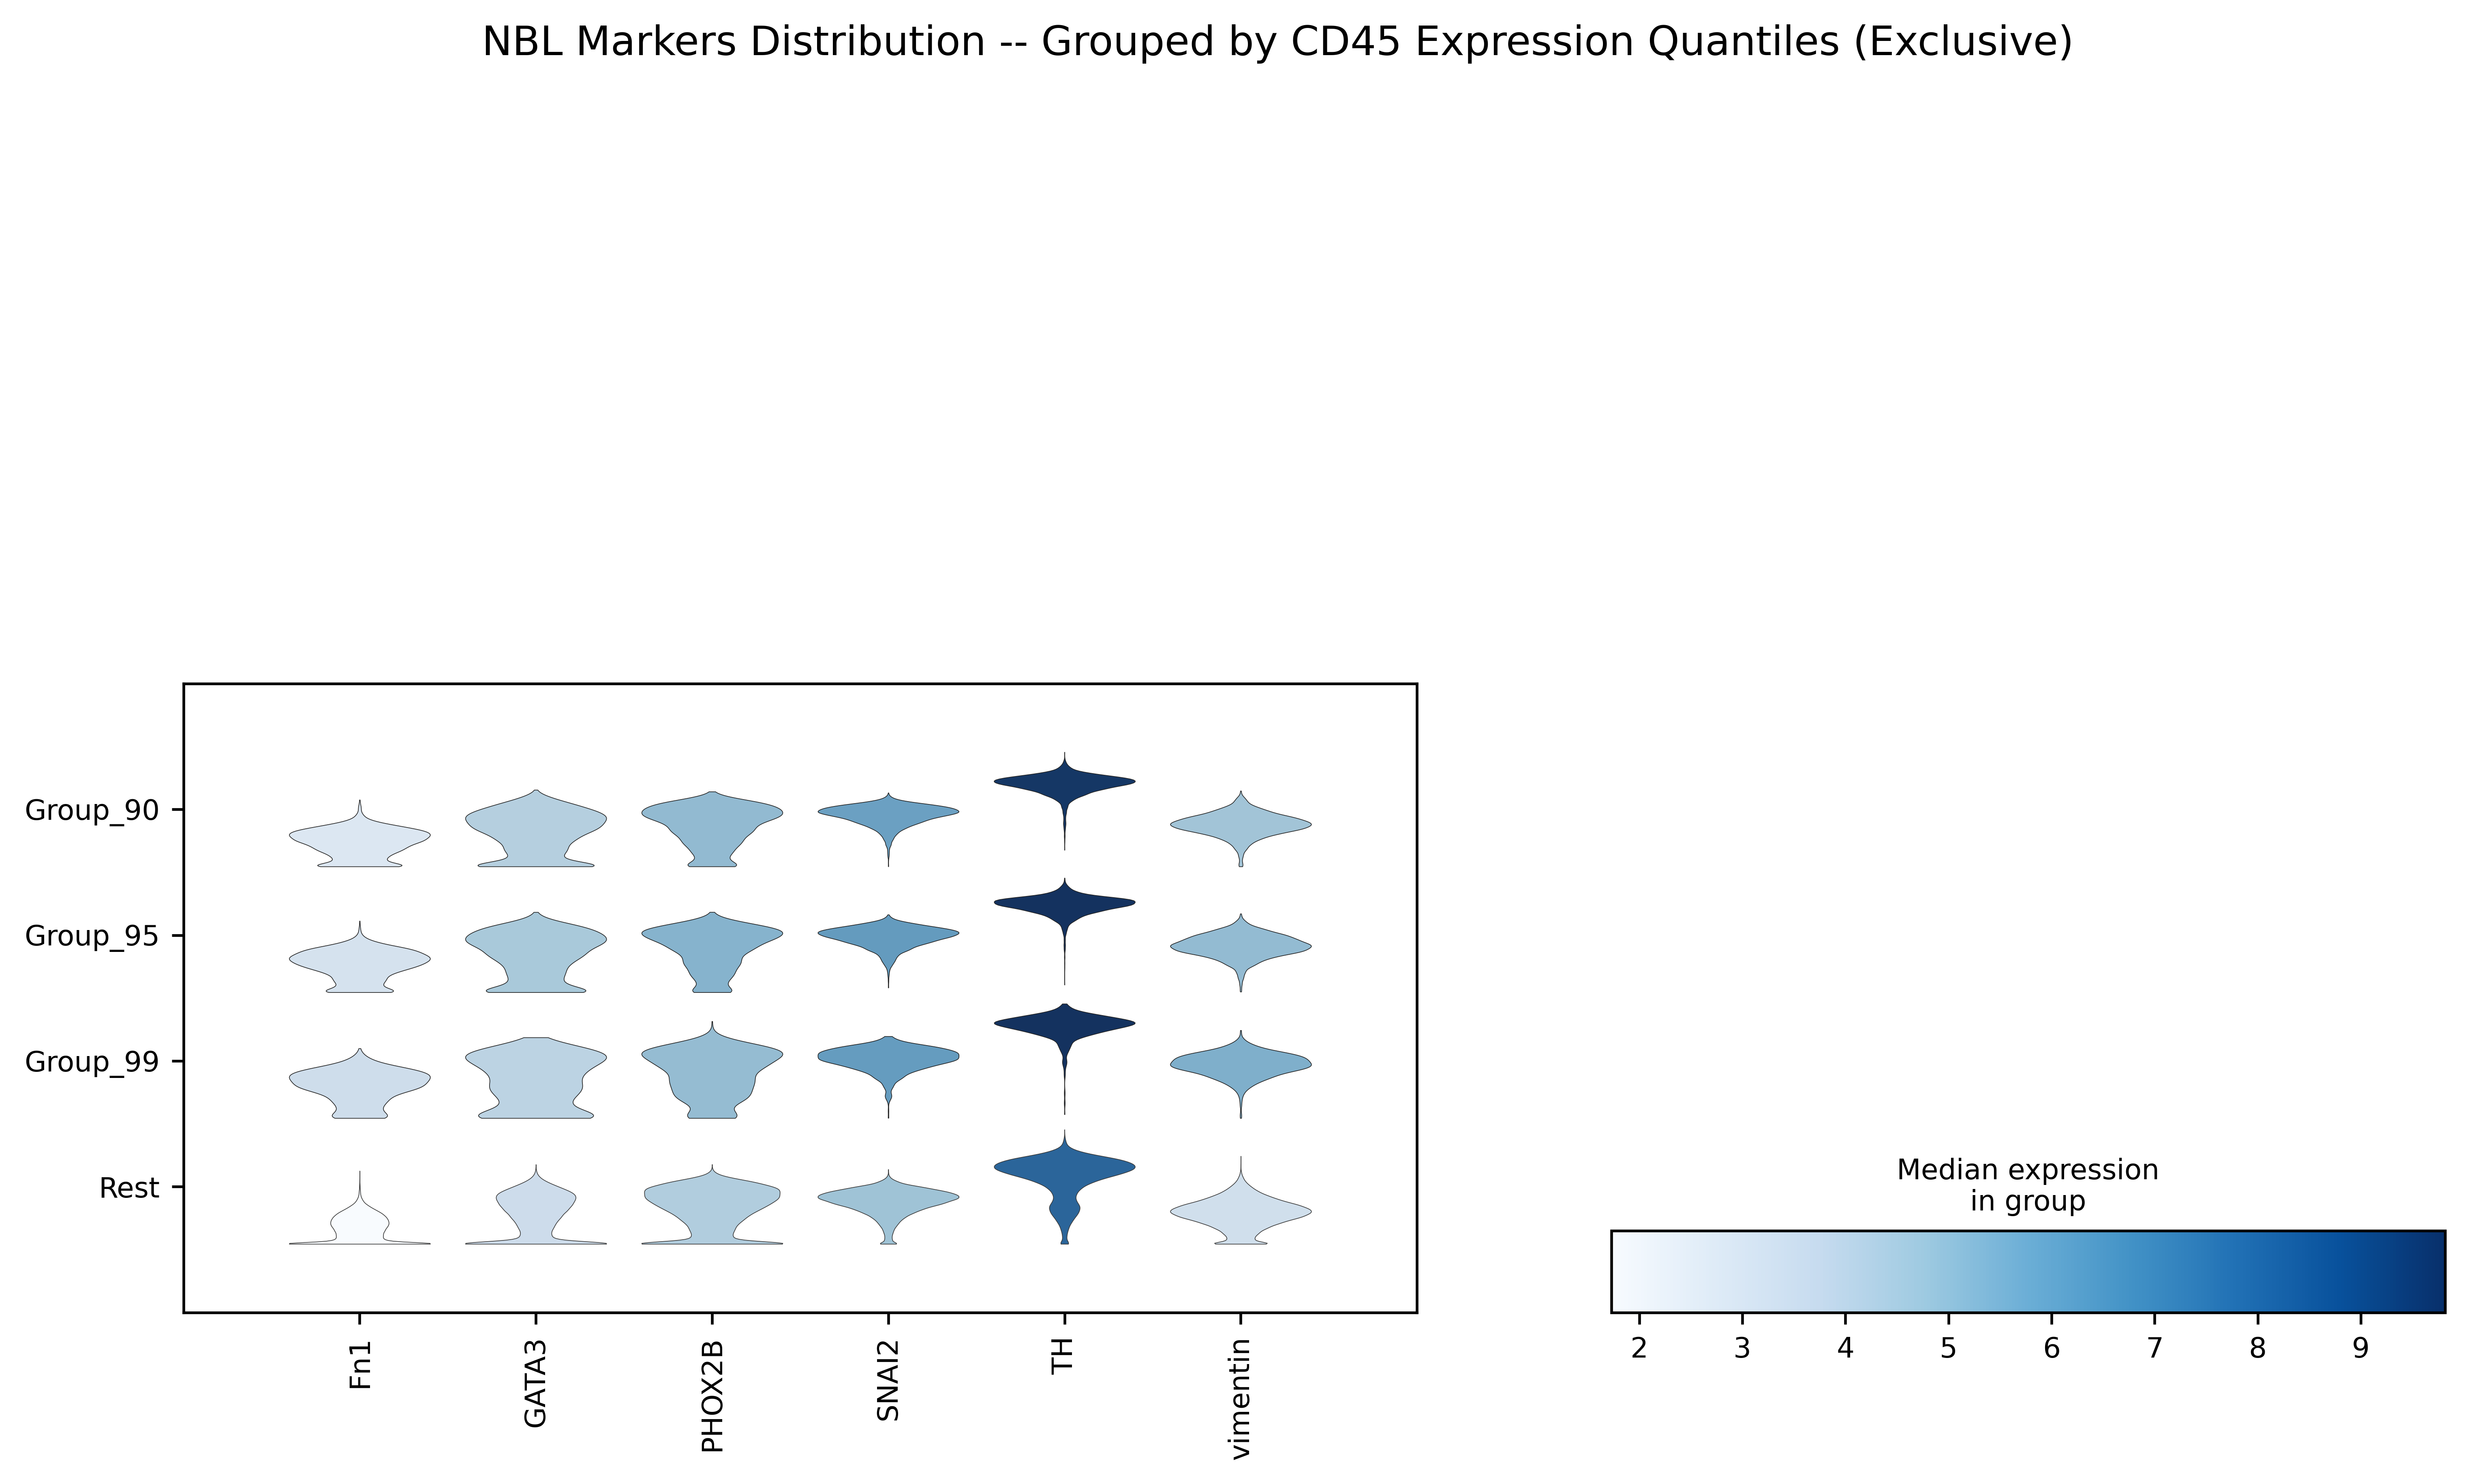

In [104]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=300, layout="constrained", sharex=True, sharey=True)
fig.suptitle(t="NBL Markers Distribution -- Grouped by CD45 Expression Quantiles (Exclusive)")
sc.pl.stacked_violin(adata=nbl_wc_NBL, var_names=nbl_markers, groupby="Group", ax=ax)
fig

In [106]:
ln.finish()

❗ cells [(3, 5), (9, 13), (13, 10), (11, 14), (14, 17), (17, 59), (59, None), (None, None), (None, 61), (61, 63), (63, 70), (70, 104)] were not run consecutively
